---
## Paso 1 — Configuración e importaciones

Datos entrada: Datos/03_Validación/Datos_bearing

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.stats import kurtosis, skew
from scipy.signal import butter, filtfilt, hilbert
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from collections import defaultdict

fs        = 51200   
base_path = 'bearing_fault_detection_reduced'
n = 8      
d = 0.7145  
D = 2.8519 

columnas = ['tachometer',         
    'acc_under_axial',   'acc_under_radial',     
    'acc_under_tangential', 'acc_over_axial',    
    'acc_over_radial','acc_over_tangential', 'microphone'          ]
COL = 1  
print('✓ Configuración cargada')

✓ Configuración cargada


---
## Paso 2 — Carga de datos

El dataset tiene tres niveles de carpetas:
```
normal/12.288.csv                          → clase/fr.csv
imbalance/6g/12.288.csv                    → clase/subclase/fr.csv
underhang/outer_race/6g/12.288.csv         → clase/subclase/subsubclase/fr.csv
```
El nombre del CSV es la frecuencia de rotación en Hz.

In [ ]:
data = []

for clase in os.listdir(base_path):
    clase_path = os.path.join(base_path, clase)
    if not os.path.isdir(clase_path):
        continue
    for elem1 in os.listdir(clase_path):
        path1 = os.path.join(clase_path, elem1)

        # CASO 1: clase/csv
        if elem1.endswith('.csv'):
            fr = float(elem1.replace('.csv', ''))
            señal = pd.read_csv(path1, header=None).values
            data.append({'clase': clase, 'subclase': None,
                         'subsubclase': None, 'fr': fr, 'señal': señal})

        elif os.path.isdir(path1):
            for elem2 in os.listdir(path1):
                path2 = os.path.join(path1, elem2)

                # CASO 2: clase/subclase/csv
                if elem2.endswith('.csv'):
                    fr = float(elem2.replace('.csv', ''))
                    señal = pd.read_csv(path2, header=None).values
                    data.append({'clase': clase, 'subclase': elem1,
                                 'subsubclase': None, 'fr': fr, 'señal': señal})

                # CASO 3: clase/subclase/subsubclase/csv
                elif os.path.isdir(path2):
                    for elem3 in os.listdir(path2):
                        if elem3.endswith('.csv'):
                            fr = float(elem3.replace('.csv', ''))
                            señal = pd.read_csv(os.path.join(path2, elem3), header=None).values
                            data.append({'clase': clase, 'subclase': elem1,
                                         'subsubclase': elem2, 'fr': fr, 'señal': señal})

print(f'Total series cargadas: {len(data)}')
print(f'  Clases: {sorted(set(s["clase"] for s in data))}')
for clase in sorted(set(s['clase'] for s in data)):
    n_serie = sum(1 for s in data if s['clase'] == clase)
    print(f'  {clase}: {n_serie} series')

✓ Total series cargadas: 168
  Clases: ['horizontal-misalignment', 'imbalance', 'normal', 'overhang', 'underhang', 'vertical-misalignment']
  horizontal-misalignment: 16 series
  imbalance: 28 series
  normal: 4 series
  overhang: 48 series
  underhang: 48 series
  vertical-misalignment: 24 series


---
## Paso 3 — Control de calidad

In [ ]:
serie_low  = next(s for s in data if s['clase'] == 'normal' and abs(s['fr'] - 12.288) < 0.01)
serie_high = next(s for s in data if s['clase'] == 'normal' and abs(s['fr'] - 61.44)  < 0.01)

for serie_ejemplo in [serie_low, serie_high]:
    señal_ej = serie_ejemplo['señal']
    fr_ej    = serie_ejemplo['fr']

    print(f'=== CONTROL DE CALIDAD — Serie normal {fr_ej:.3f} Hz = {fr_ej*60:.0f} rpm ===')
    print(f'  Forma de la señal:      {señal_ej.shape}')
    print(f'  Nº de muestras:         {len(señal_ej)}')
    print(f'  Duración:               {len(señal_ej)/fs:.2f} segundos')
    print(f'  Frecuencia de rotación: {fr_ej:.3f} Hz = {fr_ej*60:.0f} rpm')
    print(f'  Frecuencia de muestreo: {fs} Hz ✓')
    print()

    nulos = np.isnan(señal_ej).sum()
    infs  = np.isinf(señal_ej).sum()
    print(f'  Valores nulos:    {nulos}')
    print(f'  Valores infinitos:{infs}')
    print()

    print(f'  {"Sensor":<25} {"Min":>8} {"Max":>8} {"Mean":>8} {"Std":>8}')
    print('  ' + '-'*60)
    for i, col in enumerate(columnas):
        s = señal_ej[:, i]
        print(f'  {col:<25} {s.min():>8.3f} {s.max():>8.3f} {s.mean():>8.3f} {s.std():>8.3f}')

    longitudes = [s['señal'].shape[0] for s in data]
    print(f'\n  Longitud mínima:  {min(longitudes)}')
    print(f'  Longitud máxima:  {max(longitudes)}')
    print(f'  Longitud única:   {len(set(longitudes)) == 1}')
    print('\n' + '='*60 + '\n')

=== CONTROL DE CALIDAD — Serie normal 12.288 Hz = 737 rpm ===
  Forma de la señal:      (250000, 8)
  Nº de muestras:         250000
  Duración:               4.88 segundos
  Frecuencia de rotación: 12.288 Hz = 737 rpm
  Frecuencia de muestreo: 51200 Hz ✓

  Valores nulos:    0
  Valores infinitos:0

  Sensor                         Min      Max     Mean      Std
  ------------------------------------------------------------
  tachometer                  -1.126    5.108    0.003    1.586
  acc_under_axial             -3.143    1.528   -0.003    0.979
  acc_under_radial            -1.709    0.624   -0.001    0.307
  acc_under_tangential        -0.188    0.173    0.000    0.045
  acc_over_axial              -1.976    2.280    0.031    0.668
  acc_over_radial             -0.086    0.083    0.003    0.030
  acc_over_tangential         -0.791    0.655    0.005    0.198
  microphone                  -0.234    0.540    0.008    0.112

  Longitud mínima:  250000
  Longitud máxima:  250000
  Lo

---
## Paso 4 — Preprocesado

Antes de analizar la señal aplicamos:

1. **Eliminación de la media (centrado):** la señal puede tener un offset DC que no aporta información y distorsiona la FFT con un pico enorme en 0 Hz
2. **Detrend:** elimina tendencias lentas (la señal sube o baja lentamente por temperatura, etc.)
3. **Ventana de Hanning:** reduce el efecto de los bordes al calcular la FFT. Sin ventana aparecen picos falsos llamados *leakage*

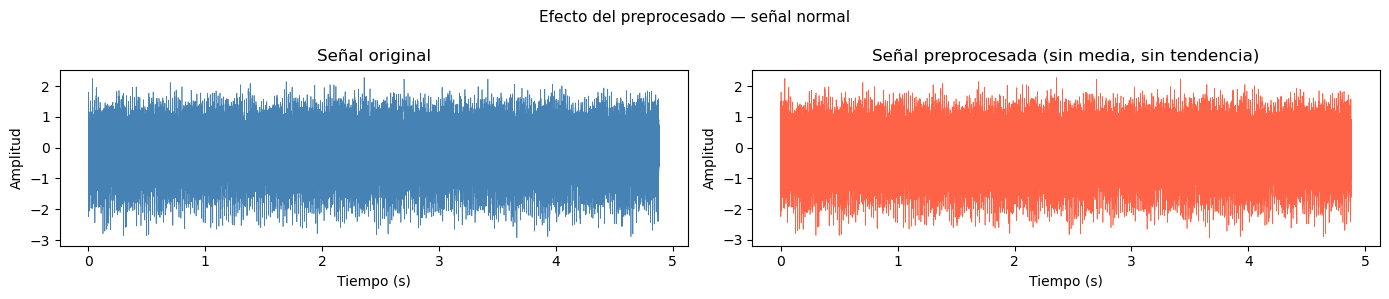

  Media original:      0.002061
  Media preprocesada:  0.000000


In [4]:
def preprocesar(señal, col=COL):
    """
    Preprocesa una señal antes del análisis:
    1. Extrae el sensor deseado
    2. Elimina la media (offset DC)
    3. Aplica detrend (elimina tendencia lineal)
    4. Aplica ventana de Hanning para la FFT

    Devuelve la señal preprocesada y la ventana por separado,
    porque la ventana solo se aplica justo antes de la FFT.
    """
    s = señal[:, col].astype(float)
    s = s - np.mean(s)                    # 1. Eliminar media
    s = s - np.polyval(np.polyfit(np.arange(len(s)), s, 1), np.arange(len(s)))  # 2. Detrend
    ventana = np.hanning(len(s))          # 3. Ventana de Hanning
    return s, ventana

# ── Visualizar efecto del preprocesado ──────────────────────────────────────
s_raw, ventana = preprocesar(señal_ej)
t = np.linspace(0, len(señal_ej)/fs, len(señal_ej))

fig, axes = plt.subplots(1, 2, figsize=(14, 3))
fig.suptitle('Efecto del preprocesado — señal normal', fontsize=11)

axes[0].plot(t, señal_ej[:, COL], color='steelblue', linewidth=0.5)
axes[0].set_title('Señal original')
axes[0].set_xlabel('Tiempo (s)')
axes[0].set_ylabel('Amplitud')

axes[1].plot(t, s_raw, color='tomato', linewidth=0.5)
axes[1].set_title('Señal preprocesada (sin media, sin tendencia)')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Amplitud')

plt.tight_layout()
plt.show()
print(f'  Media original:      {señal_ej[:, COL].mean():.6f}')
print(f'  Media preprocesada:  {s_raw.mean():.6f}')

---
## Paso 5 — Análisis en dominio temporal

Analizamos la señal **en el tiempo** antes de transformarla. Esto nos da información sobre la naturaleza de la vibración:

| Métrica | Qué mide | Útil para |
|---|---|---|
| **RMS** | Energía total de la vibración | Imbalance, misalignment |
| **Kurtosis** | Golpes impulsivos bruscos | Fallos de rodamiento |
| **Crest factor** | Picos sobre el nivel medio | Fallos incipientes |
| **Skewness** | Asimetría de la vibración | Desgaste unilateral |

Serie                     RMS   Kurtosis    Crest   Skewness     Peak
----------------------------------------------------------------
Normal 737 rpm         0.9792    -1.0657   3.2069    -0.2965   3.1401
Normal 3686 rpm        0.6273     0.1277   4.6703    -0.2240   2.9296


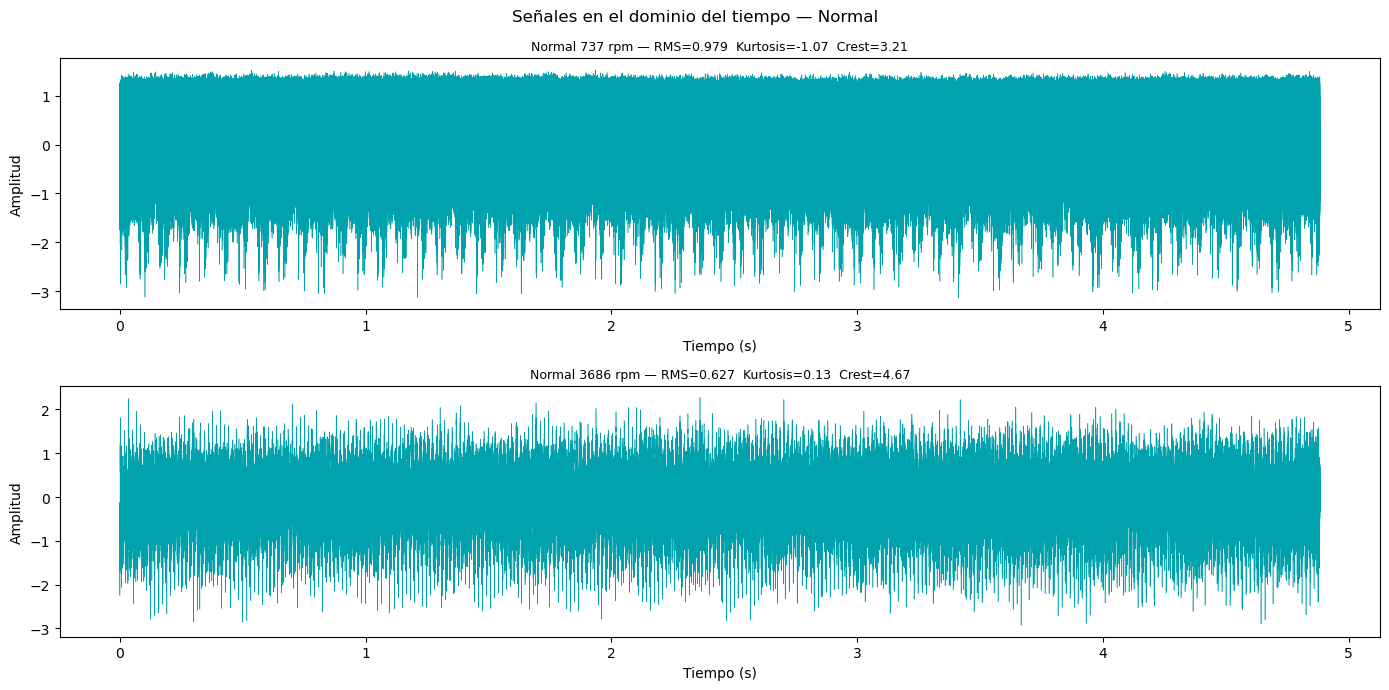

In [ ]:
def analisis_temporal(s):
    """Calcula los estadísticos temporales de una señal preprocesada."""
    rms   = np.sqrt(np.mean(s**2))
    kurt  = kurtosis(s)
    crest = np.max(np.abs(s)) / (rms + 1e-10)
    sk    = skew(s)
    peak  = np.max(np.abs(s))
    return {'RMS': rms, 'Kurtosis': kurt, 'Crest': crest, 'Skewness': sk, 'Peak': peak}

series_comp = [('Normal 737 rpm',  serie_low),('Normal 3686 rpm', serie_high),]

print(f'{"Serie":<20} {"RMS":>8} {"Kurtosis":>10} {"Crest":>8} {"Skewness":>10} {"Peak":>8}')
for titulo, serie in series_comp:
    s, _ = preprocesar(serie['señal'])
    m = analisis_temporal(s)
    print(f'{titulo:<20} {m["RMS"]:>8.4f} {m["Kurtosis"]:>10.4f} {m["Crest"]:>8.4f} {m["Skewness"]:>10.4f} {m["Peak"]:>8.4f}')

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle('Señales en el dominio del tiempo — Normal', fontsize=12)
for ax, (titulo, serie) in zip(axes, series_comp):
    s, _ = preprocesar(serie['señal'])
    t = np.linspace(0, len(s)/fs, len(s))
    ax.plot(t, s, linewidth=0.4, color='#00a3ad')
    m = analisis_temporal(s)
    ax.set_title(f'{titulo} — RMS={m["RMS"]:.3f}  Kurtosis={m["Kurtosis"]:.2f}  Crest={m["Crest"]:.2f}',
                 fontsize=9)
    ax.set_xlabel('Tiempo (s)')
    ax.set_ylabel('Amplitud')
plt.tight_layout()
plt.show()


=== Normal 737 rpm ===
Sensor                         RMS   Kurtosis    Crest   Skewness     Peak
--------------------------------------------------------------------
tachometer                  1.5856     4.3044   3.2187     2.5004   5.1035
acc_under_axial             0.9792    -1.0657   3.2069    -0.2965   3.1401
acc_under_radial            0.3074    -0.7259   5.5580    -0.3917   1.7083
acc_under_tangential        0.0448    -0.3774   4.2132    -0.2182   0.1888
acc_over_axial              0.6681    -0.3859   3.3709     0.1644   2.2520
acc_over_radial             0.0302    -0.7675   2.9400    -0.0935   0.0888
acc_over_tangential         0.1973    -0.2521   4.0400    -0.0594   0.7970
microphone                  0.1121     0.0650   4.7455     0.6854   0.5322

=== Normal 3686 rpm ===
Sensor                         RMS   Kurtosis    Crest   Skewness     Peak
--------------------------------------------------------------------
tachometer                  1.7856     2.1304   2.7563     2.02

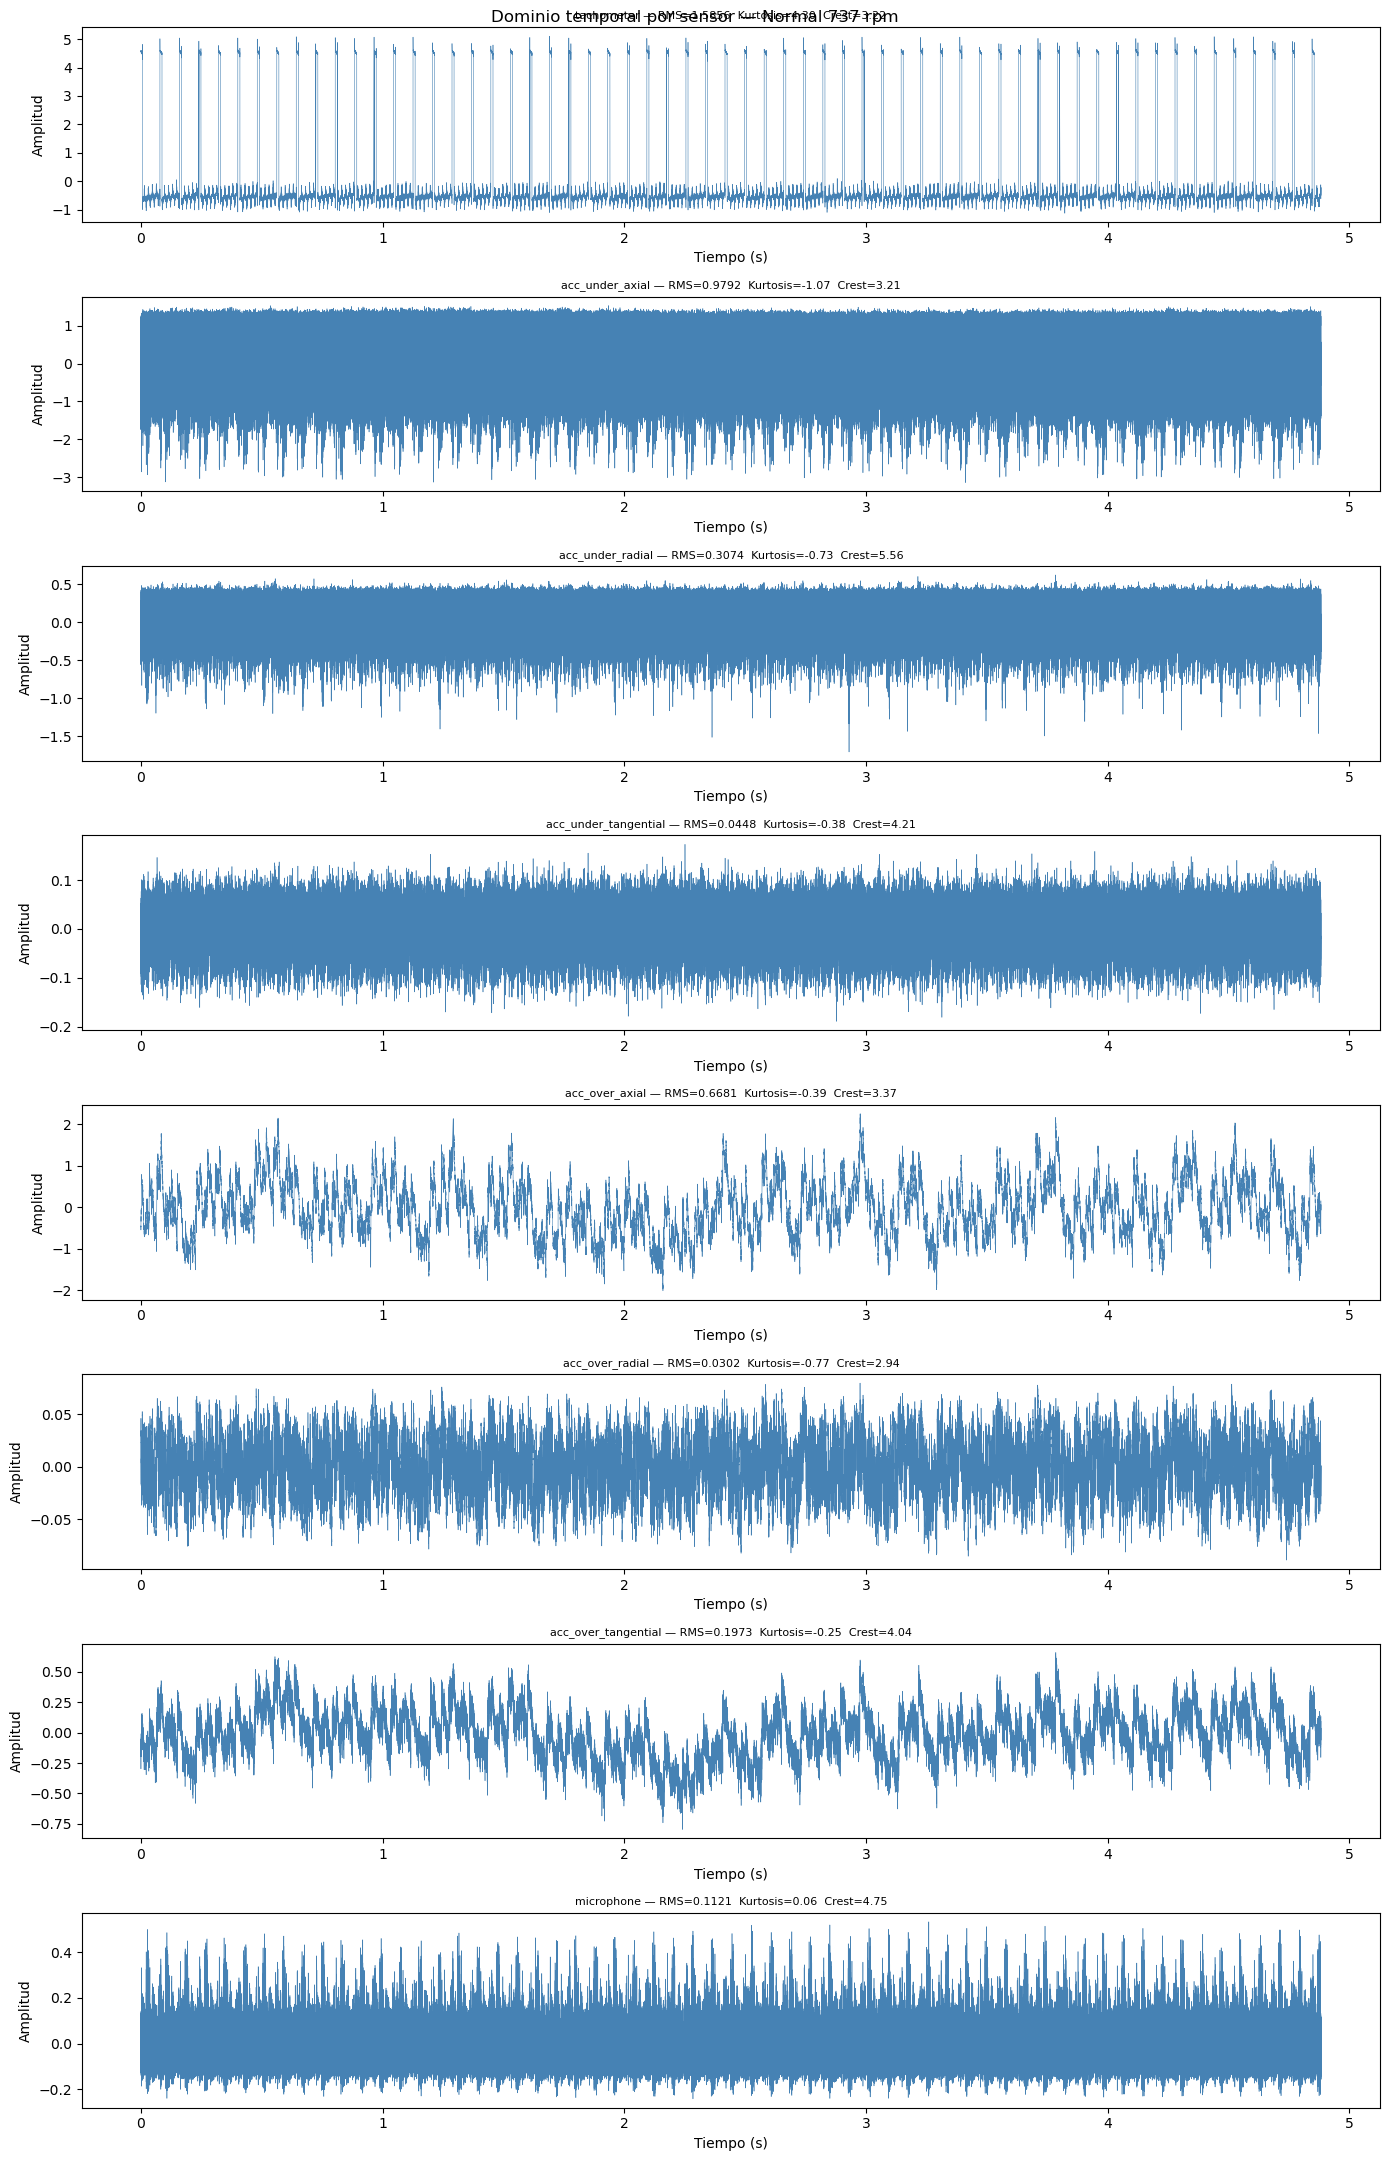

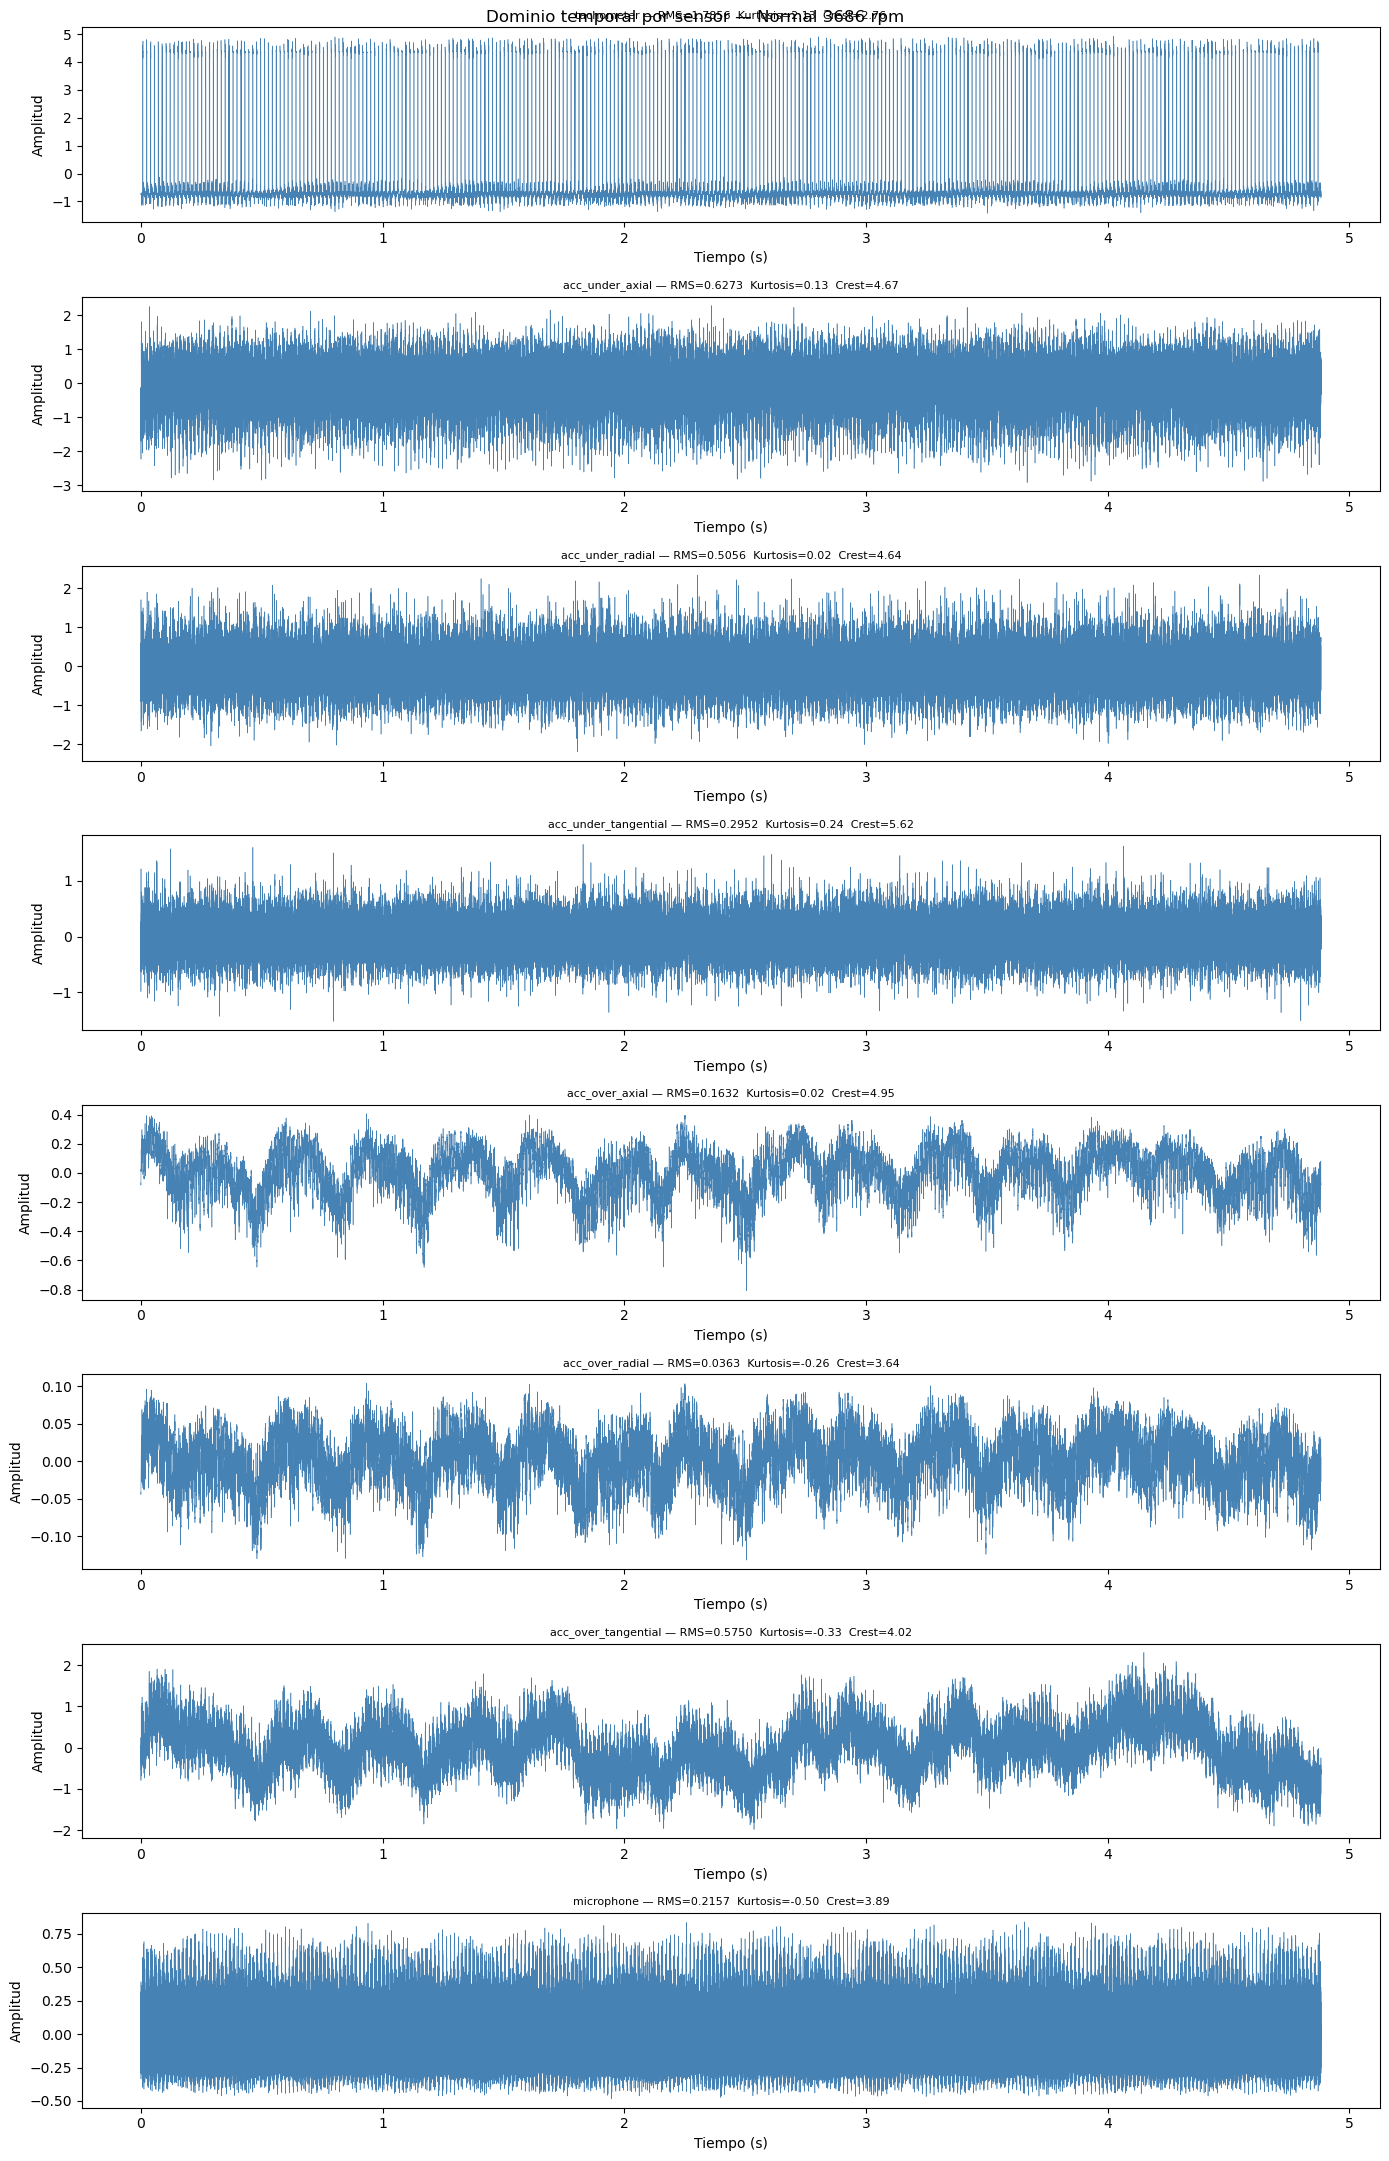

In [ ]:
def analisis_temporal(s):
    rms   = np.sqrt(np.mean(s**2))
    kurt  = kurtosis(s)
    crest = np.max(np.abs(s)) / (rms + 1e-10)
    sk    = skew(s)
    peak  = np.max(np.abs(s))
    return {'RMS': rms, 'Kurtosis': kurt, 'Crest': crest, 'Skewness': sk, 'Peak': peak}

series_comp = [
    ('Normal 737 rpm',  serie_low),('Normal 3686 rpm', serie_high),]

for titulo, serie in series_comp:
    print(f'\n=== {titulo} ===')
    print(f'{"Sensor":<25} {"RMS":>8} {"Kurtosis":>10} {"Crest":>8} {"Skewness":>10} {"Peak":>8}')
    print('-' * 68)
    for i, col in enumerate(columnas):
        s, _ = preprocesar(serie['señal'], col=i)
        m = analisis_temporal(s)
        print(f'{col:<25} {m["RMS"]:>8.4f} {m["Kurtosis"]:>10.4f} {m["Crest"]:>8.4f} {m["Skewness"]:>10.4f} {m["Peak"]:>8.4f}')

for titulo, serie in series_comp:
    fig, axes = plt.subplots(8, 1, figsize=(14, 22))
    fig.suptitle(f'Dominio temporal por sensor — {titulo}', fontsize=12)

    for ax, (i, col) in zip(axes, enumerate(columnas)):
        s, _ = preprocesar(serie['señal'], col=i)
        t = np.linspace(0, len(s)/fs, len(s))
        m = analisis_temporal(s)
        ax.plot(t, s, linewidth=0.4, color='steelblue')
        ax.set_title(
            f'{col} — RMS={m["RMS"]:.4f}  Kurtosis={m["Kurtosis"]:.2f}  Crest={m["Crest"]:.2f}',
            fontsize=8)
        ax.set_xlabel('Tiempo (s)')
        ax.set_ylabel('Amplitud')

    plt.tight_layout()
    plt.show()

---
## Paso 6 — Análisis en frecuencia (FFT)

La FFT transforma la señal del **dominio del tiempo** al **dominio de la frecuencia**.

- **Dominio del tiempo:** ves cómo varía la vibración segundo a segundo
- **Dominio de la frecuencia:** ves a qué frecuencias vibra y con qué intensidad

Cada pico en el espectro representa una vibración que se repite a ese ritmo. Si aparece un pico en BPFO, significa que algo golpea la pista exterior del rodamiento a esa frecuencia.

In [ ]:
def calcular_fc(fr):
    """Calcula las frecuencias características en RPM para una fr dada en Hz."""
    return {'fr':   fr * 60,
        'BPFO': (n/2) * fr * (1 - d/D) * 60,'BPFI': (n/2) * fr * (1 + d/D) * 60,
        'BSF':  (D/(2*d)) * fr * (1 - (d/D)**2) * 60,'FTF':  (fr/2) * (1 - d/D) * 60,}


  ANÁLISIS EN FRECUENCIA — Normal 737 rpm

  Sensor: tachometer
  Armónico      RPM teórico          Amp
  ----------------------------------------
  1x fr               737.3     0.480243 ◄
  2x fr              1474.6     0.491129 ◄
  3x fr              2211.8     0.431001 ◄
  4x fr              2949.1     0.346907 ◄
  5x fr              3686.4     0.296122 ◄


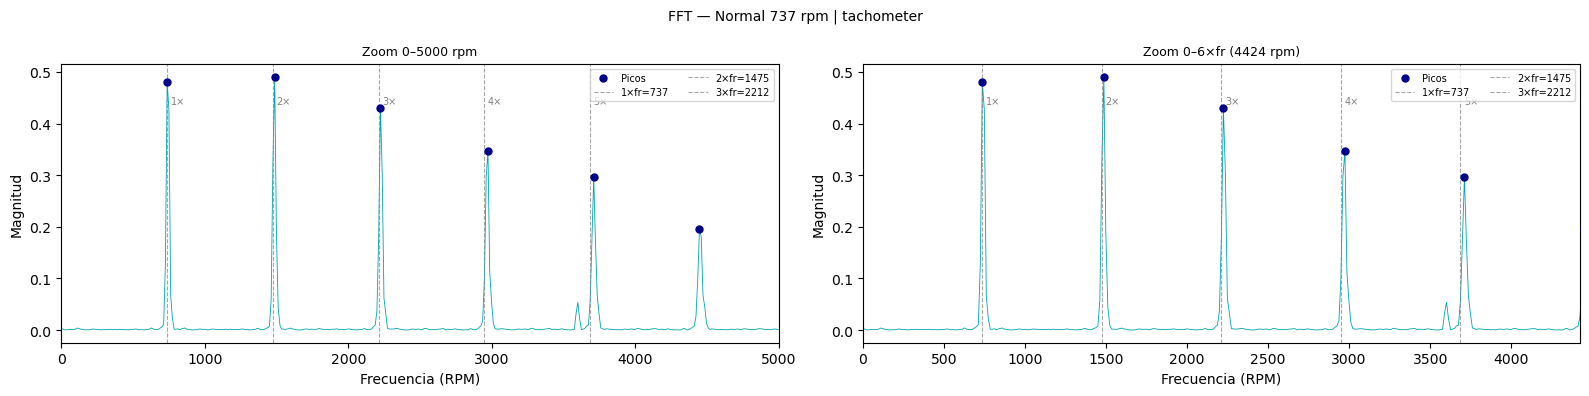


  Sensor: acc_under_axial
  Armónico      RPM teórico          Amp
  ----------------------------------------
  1x fr               737.3     0.068237 ◄
  2x fr              1474.6     0.002276 ◄
  3x fr              2211.8     0.059590 ◄
  4x fr              2949.1     0.003704 ◄
  5x fr              3686.4     0.017303 ◄


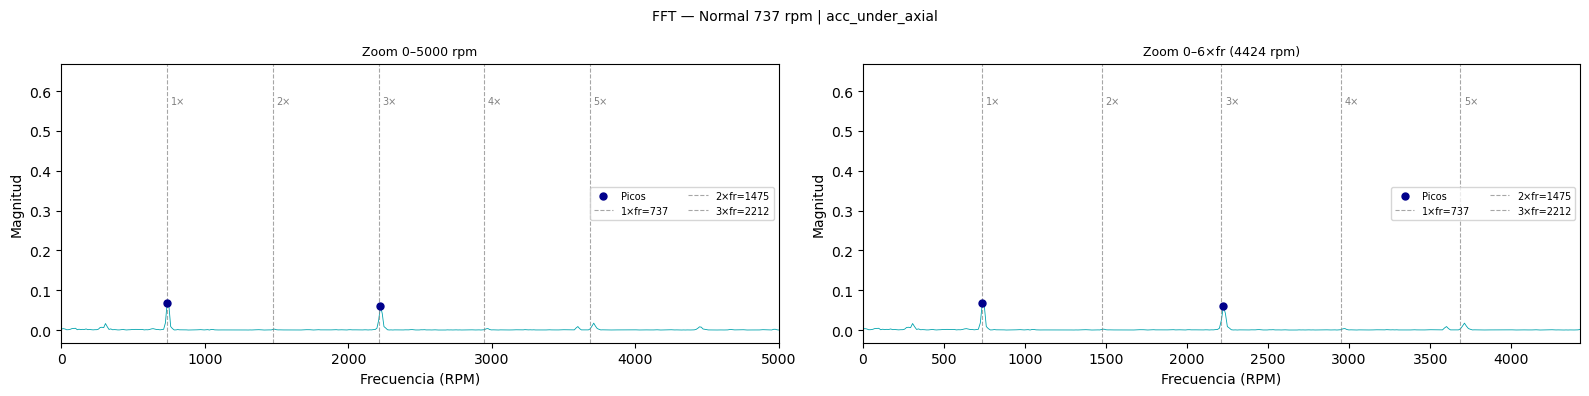


  Sensor: acc_under_radial
  Armónico      RPM teórico          Amp
  ----------------------------------------
  1x fr               737.3     0.009166 ◄
  2x fr              1474.6     0.011549 ◄
  3x fr              2211.8     0.008874 ◄
  4x fr              2949.1     0.005130 ◄
  5x fr              3686.4     0.010625 ◄


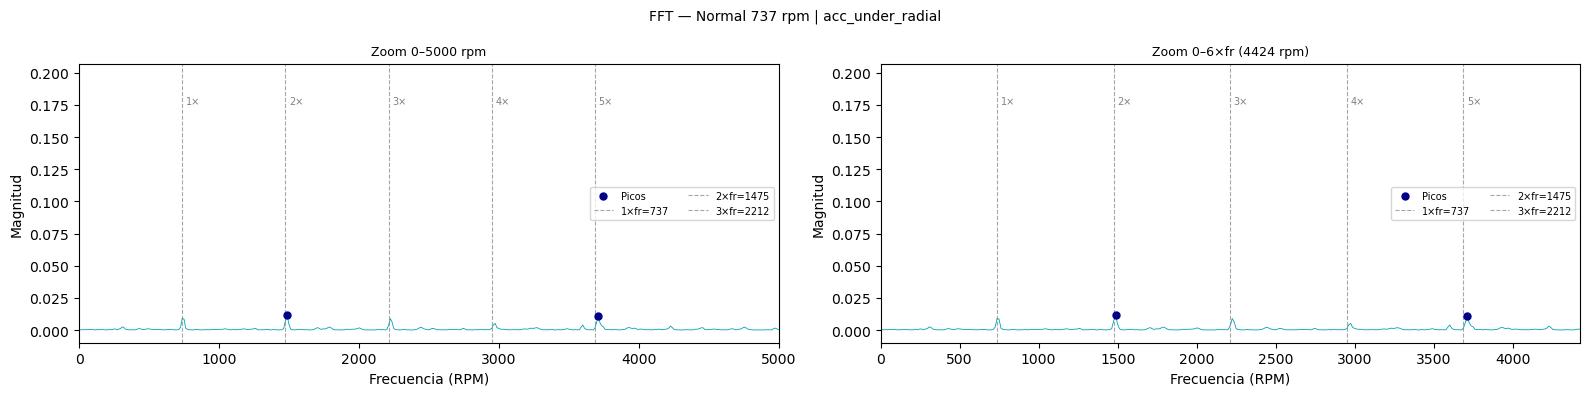


  Sensor: acc_under_tangential
  Armónico      RPM teórico          Amp
  ----------------------------------------
  1x fr               737.3     0.002113 ◄
  2x fr              1474.6     0.001361 ◄
  3x fr              2211.8     0.002397 ◄
  4x fr              2949.1     0.001424 ◄
  5x fr              3686.4     0.000857 ◄


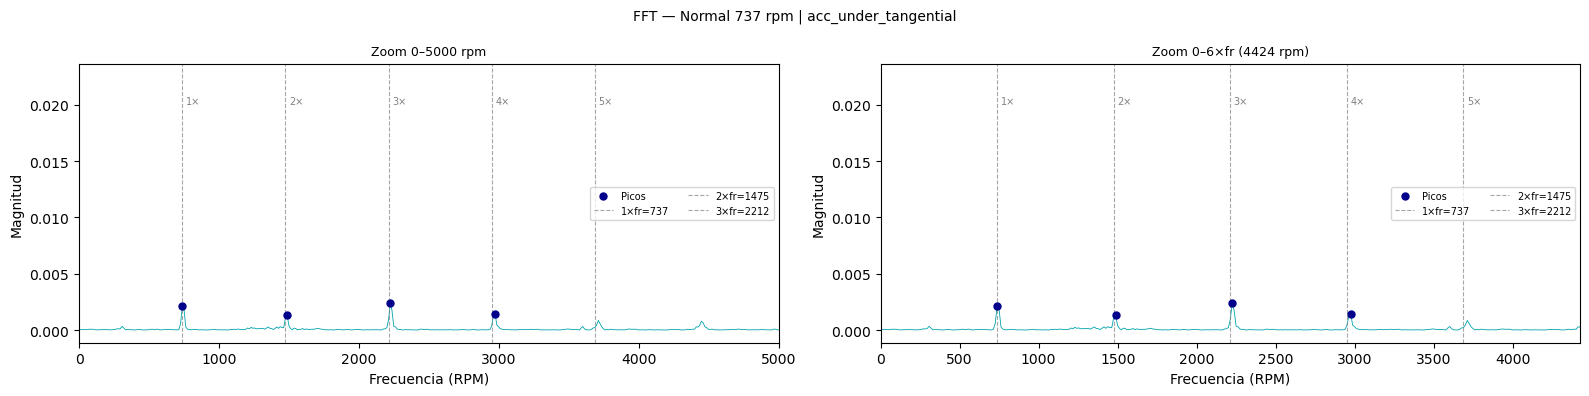


  Sensor: acc_over_axial
  Armónico      RPM teórico          Amp
  ----------------------------------------
  1x fr               737.3     0.138723 ◄
  2x fr              1474.6     0.181336 ◄
  3x fr              2211.8     0.035874 ◄
  4x fr              2949.1     0.036254 ◄
  5x fr              3686.4     0.074307 ◄


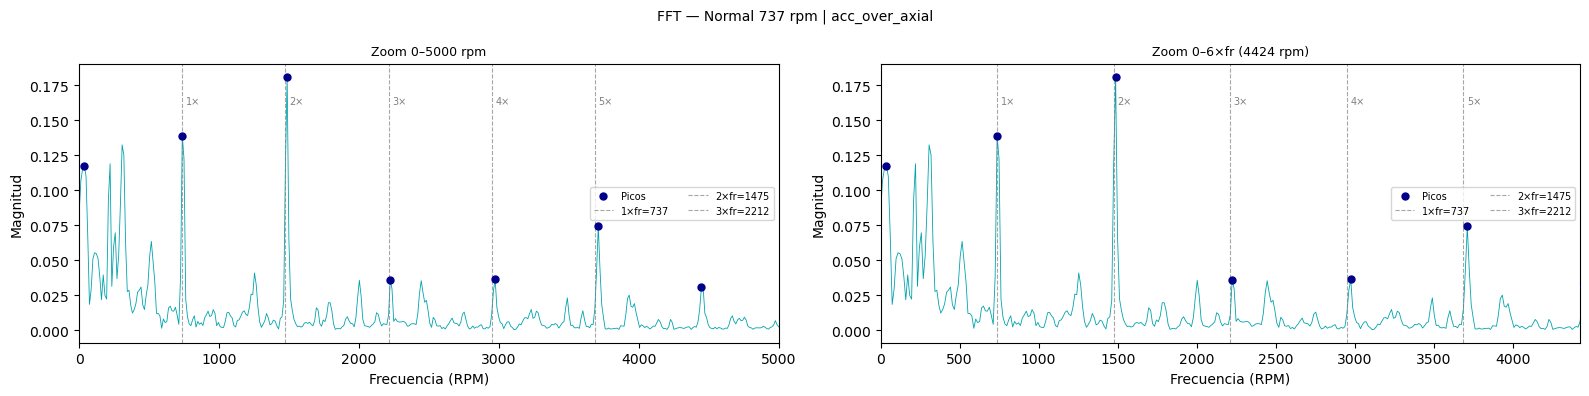


  Sensor: acc_over_radial
  Armónico      RPM teórico          Amp
  ----------------------------------------
  1x fr               737.3     0.003630 ◄
  2x fr              1474.6     0.004052 ◄
  3x fr              2211.8     0.001196 ◄
  4x fr              2949.1     0.000737 ◄
  5x fr              3686.4     0.001658 ◄


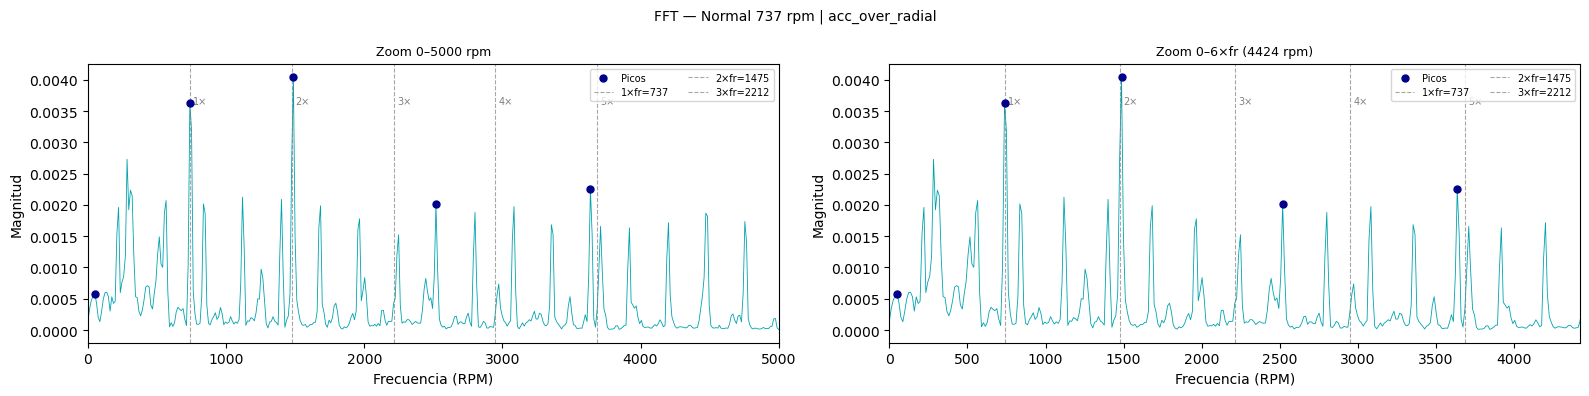


  Sensor: acc_over_tangential
  Armónico      RPM teórico          Amp
  ----------------------------------------
  1x fr               737.3     0.039187 ◄
  2x fr              1474.6     0.049285 ◄
  3x fr              2211.8     0.010806 ◄
  4x fr              2949.1     0.010229 ◄
  5x fr              3686.4     0.018331 ◄


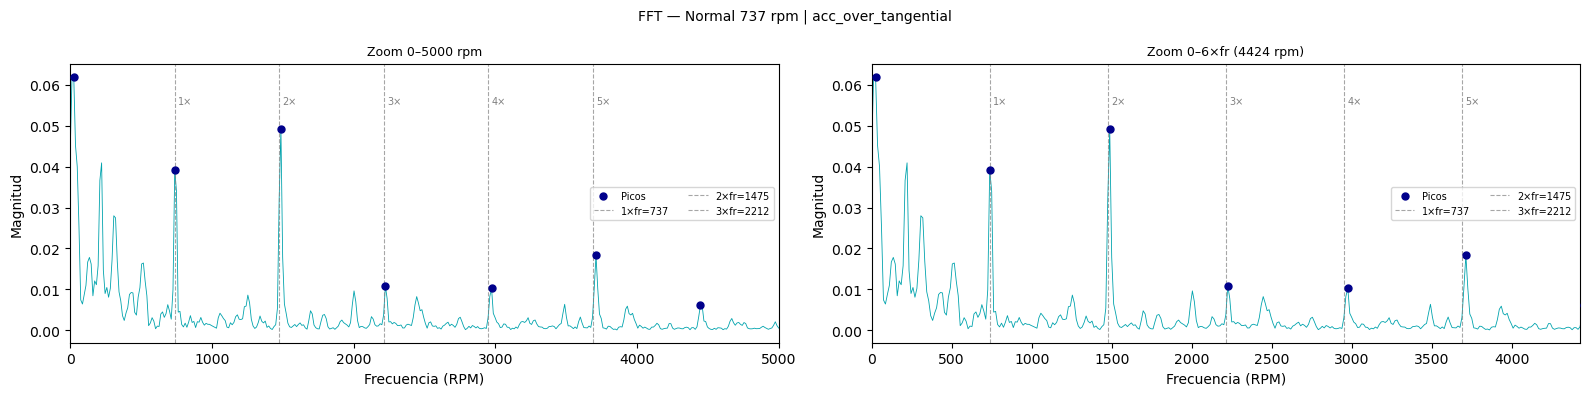


  Sensor: microphone
  Armónico      RPM teórico          Amp
  ----------------------------------------
  1x fr               737.3     0.009478 ◄
  2x fr              1474.6     0.001884 ◄
  3x fr              2211.8     0.008826 ◄
  4x fr              2949.1     0.005676 ◄
  5x fr              3686.4     0.001917 ◄


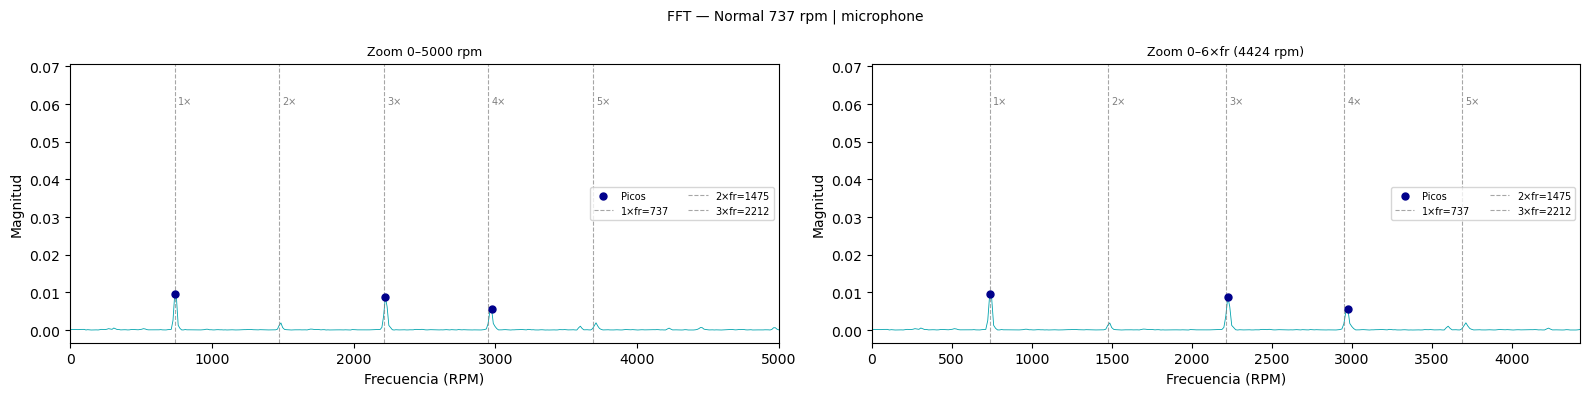


  ANÁLISIS EN FRECUENCIA — Normal 3686 rpm

  Sensor: tachometer
  Armónico      RPM teórico          Amp
  ----------------------------------------
  1x fr              3686.4     0.686258 ◄
  2x fr              7372.8     0.566107 ◄
  3x fr             11059.2     0.479250 ◄
  4x fr             14745.6     0.384034 ◄
  5x fr             18432.0     0.247841 ◄


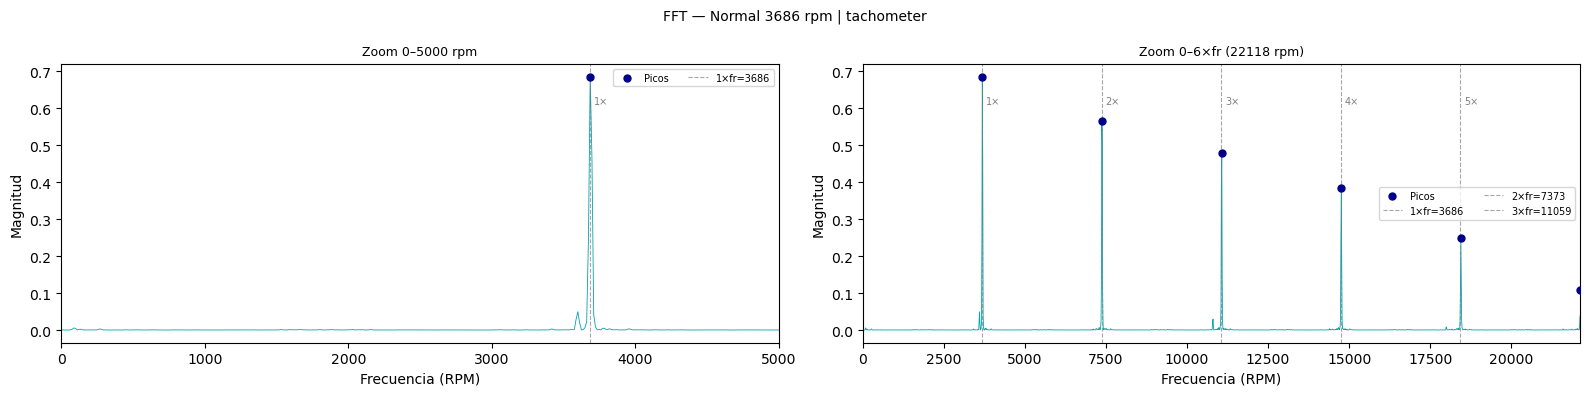


  Sensor: acc_under_axial
  Armónico      RPM teórico          Amp
  ----------------------------------------
  1x fr              3686.4     0.116821 ◄
  2x fr              7372.8     0.033910 ◄
  3x fr             11059.2     0.148631 ◄
  4x fr             14745.6     0.038151 ◄
  5x fr             18432.0     0.026076 ◄


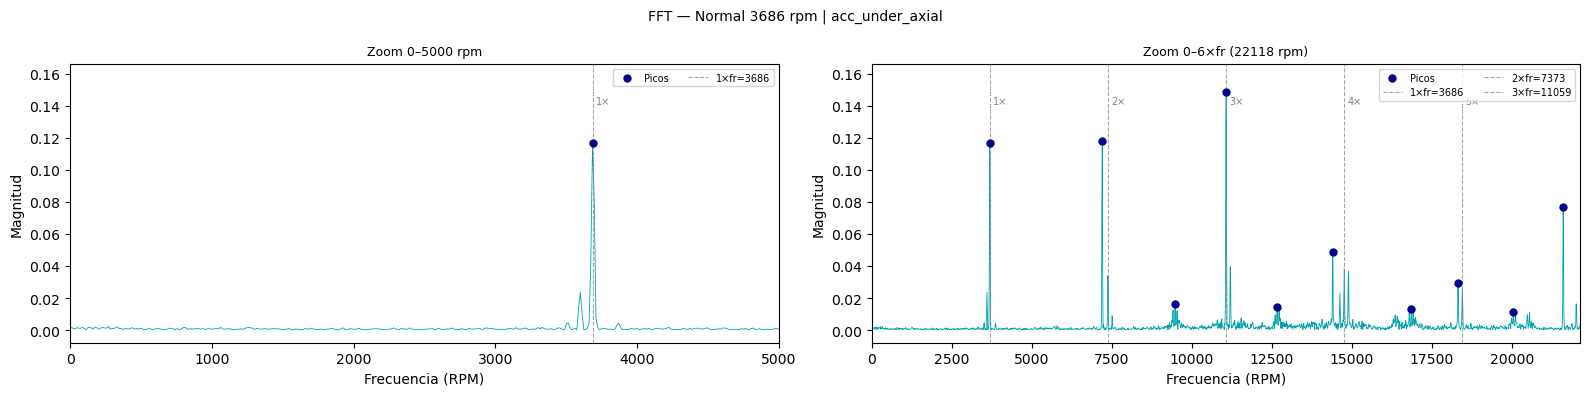


  Sensor: acc_under_radial
  Armónico      RPM teórico          Amp
  ----------------------------------------
  1x fr              3686.4     0.118829 ◄
  2x fr              7372.8     0.009947 ◄
  3x fr             11059.2     0.031649 ◄
  4x fr             14745.6     0.061441 ◄
  5x fr             18432.0     0.034420 ◄


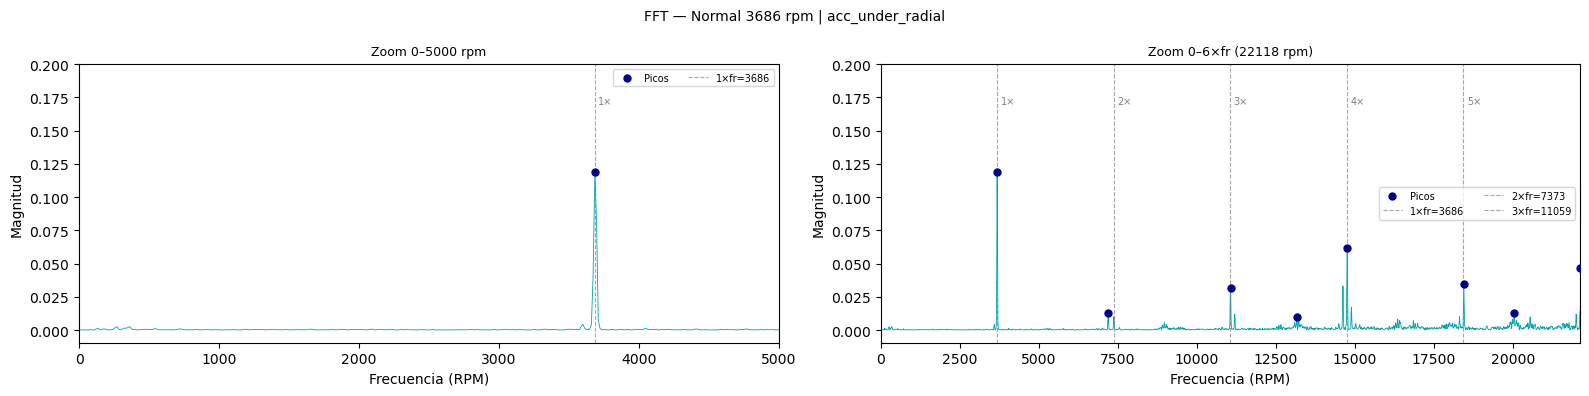


  Sensor: acc_under_tangential
  Armónico      RPM teórico          Amp
  ----------------------------------------
  1x fr              3686.4     0.030121 ◄
  2x fr              7372.8     0.016824 ◄
  3x fr             11059.2     0.053618 ◄
  4x fr             14745.6     0.028259 ◄
  5x fr             18432.0     0.021187 ◄


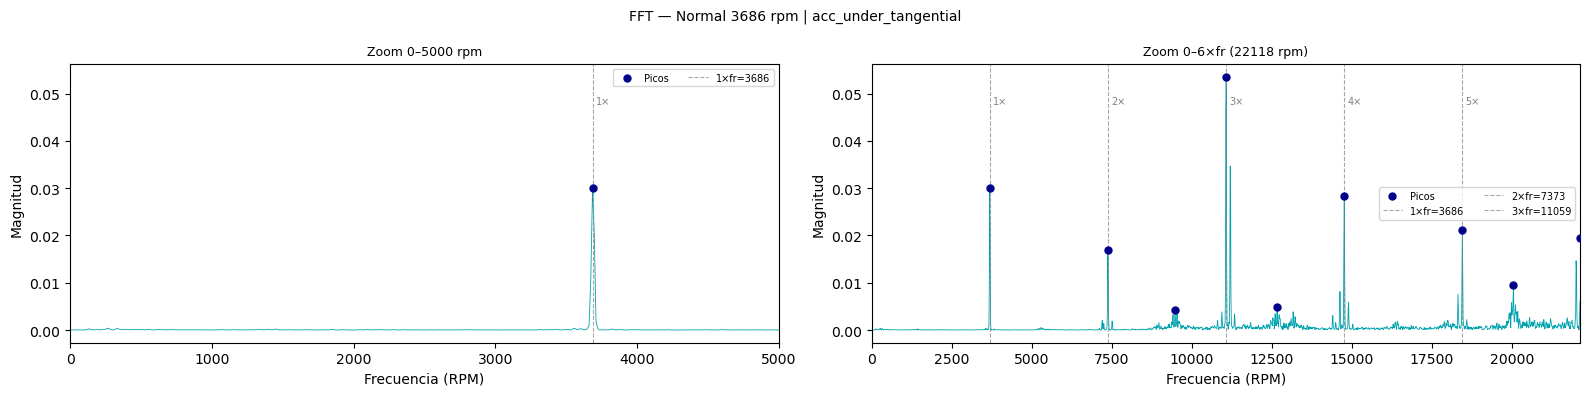


  Sensor: acc_over_axial
  Armónico      RPM teórico          Amp
  ----------------------------------------
  1x fr              3686.4     0.011141 ◄
  2x fr              7372.8     0.017447 ◄
  3x fr             11059.2     0.020205 ◄
  4x fr             14745.6     0.028592 ◄
  5x fr             18432.0     0.015505 ◄


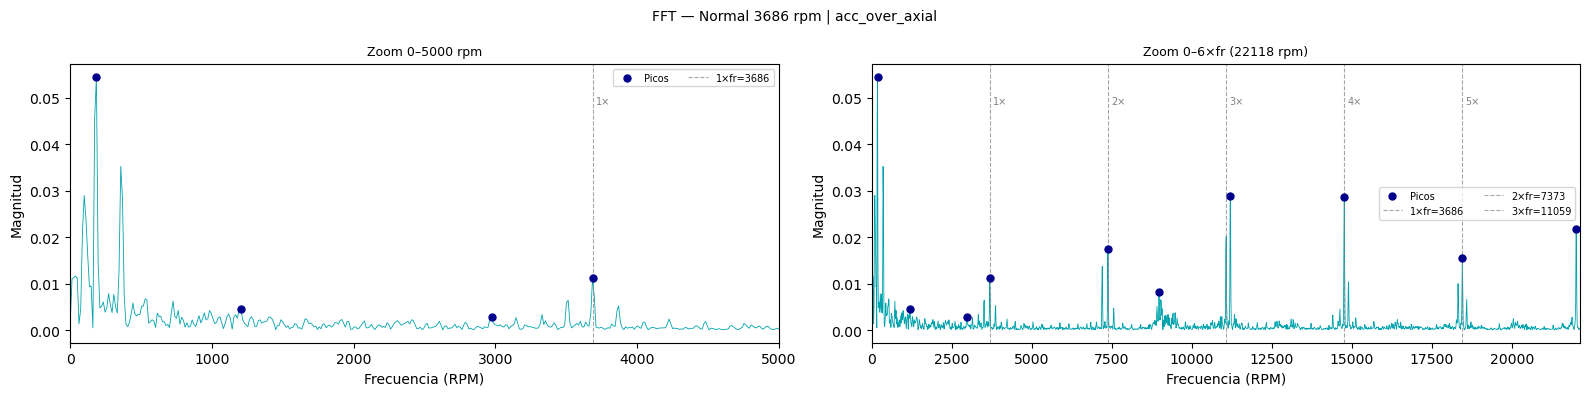


  Sensor: acc_over_radial
  Armónico      RPM teórico          Amp
  ----------------------------------------
  1x fr              3686.4     0.003229 ◄
  2x fr              7372.8     0.002464 ◄
  3x fr             11059.2     0.002738 ◄
  4x fr             14745.6     0.004624 ◄
  5x fr             18432.0     0.002817 ◄


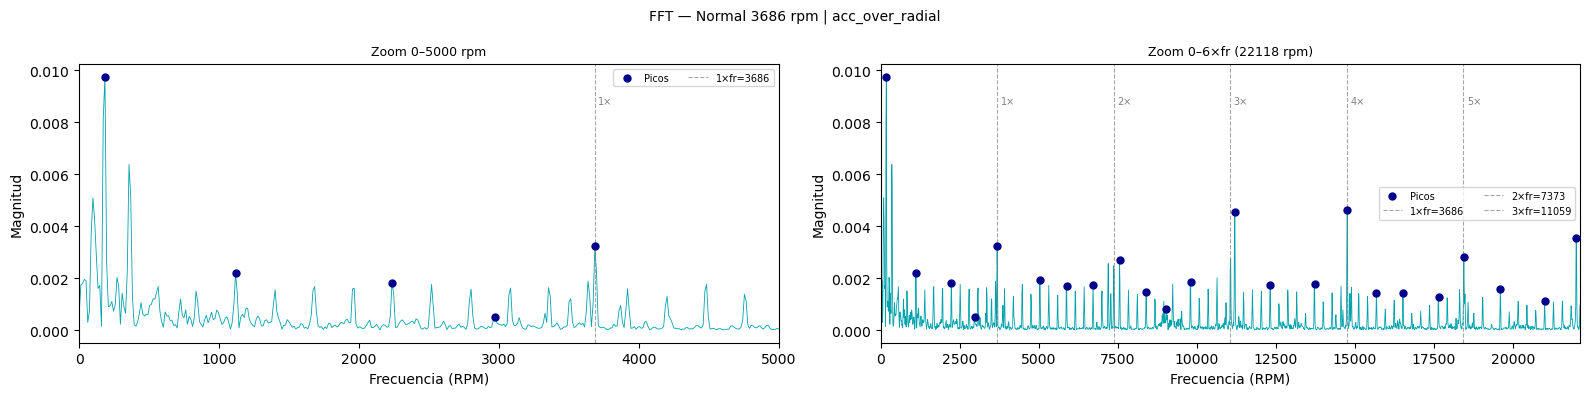


  Sensor: acc_over_tangential
  Armónico      RPM teórico          Amp
  ----------------------------------------
  1x fr              3686.4     0.119894 ◄
  2x fr              7372.8     0.016302 ◄
  3x fr             11059.2     0.039421 ◄
  4x fr             14745.6     0.051390 ◄
  5x fr             18432.0     0.023694 ◄


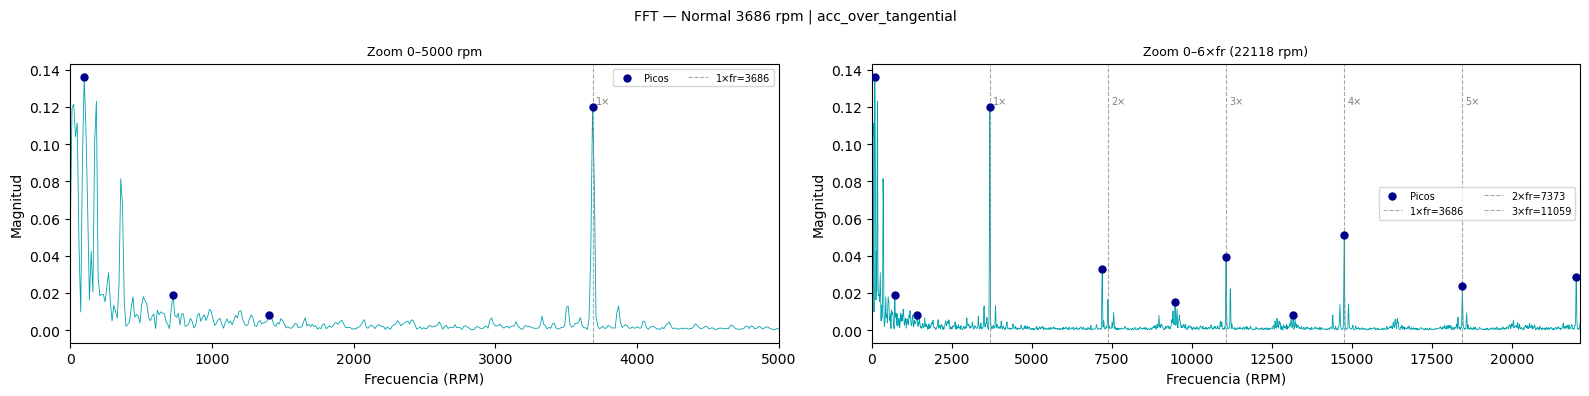


  Sensor: microphone
  Armónico      RPM teórico          Amp
  ----------------------------------------
  1x fr              3686.4     0.014300 ◄
  2x fr              7372.8     0.003224 ◄
  3x fr             11059.2     0.010978 ◄
  4x fr             14745.6     0.005015 ◄
  5x fr             18432.0     0.003433 ◄


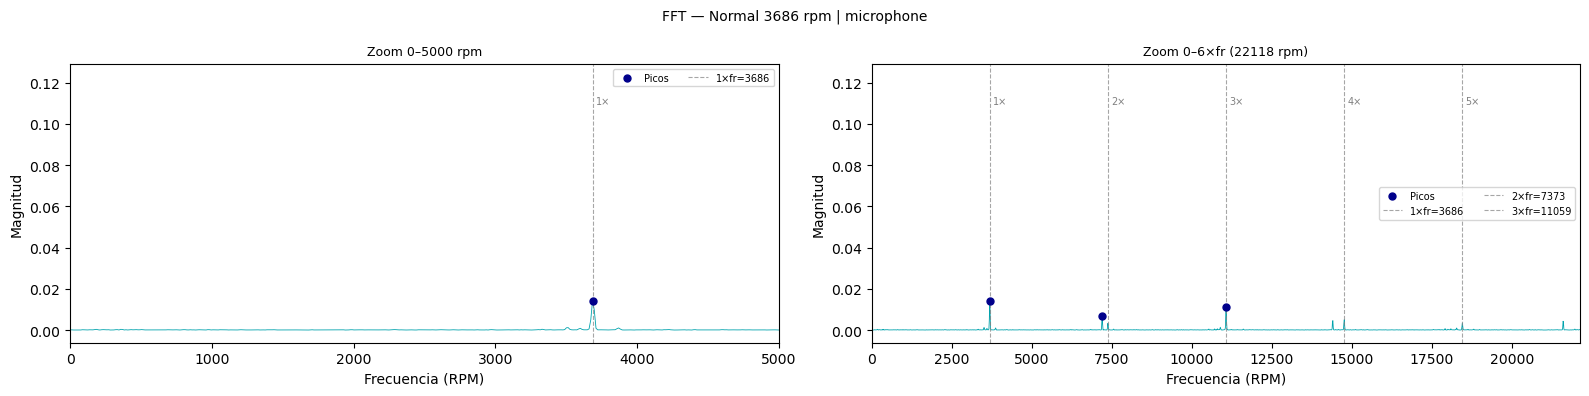

In [ ]:
from scipy.signal import find_peaks

for titulo, serie in series_comp:
    señal = serie['señal']
    fr    = serie['fr']
    fc    = calcular_fc(fr)

    print(f'\n{"="*70}')
    print(f'  ANÁLISIS EN FRECUENCIA — {titulo}')
    print(f'{"="*70}')

    for i, col in enumerate(columnas):

        # 1. Aplicar ventana
        s, ventana = preprocesar(señal, col=i)
        s_ventana  = s * ventana

        # 2. Calcular FFT
        rfft_out  = np.fft.rfft(s_ventana)
        fft_vals  = np.abs(rfft_out) / len(rfft_out)
        freqs_rpm = np.fft.rfftfreq(len(s_ventana), d=1/fs) * 60

        # 3. Obtener espectro + 4. Buscar picos
        picos_idx, props = find_peaks(fft_vals, height=np.max(fft_vals)*0.05, distance=50)
        picos_rpm = freqs_rpm[picos_idx]
        picos_mag = fft_vals[picos_idx]

        # 5. Comparar con 1x, 2x, 3x fr
        fr_rpm     = fr * 60
        armonicos  = {f'{k}x fr': fr_rpm * k for k in range(1, 6)}

        print(f'\n  Sensor: {col}')
        print(f'  {"Armónico":<10} {"RPM teórico":>14} {"Amp":>12}')
        print('  ' + '-'*40)
        for nombre_arm, rpm_arm in armonicos.items():
            mask = np.abs(freqs_rpm - rpm_arm) < 30
            amp  = float(np.max(fft_vals[mask])) if mask.any() else 0.0
            flag = ' ◄' if amp > np.mean(fft_vals) * 5 else ''
            print(f'  {nombre_arm:<10} {rpm_arm:>14.1f} {amp:>12.6f}{flag}')

        fig, axes = plt.subplots(1, 2, figsize=(16, 4))
        fig.suptitle(f'FFT — {titulo} | {col}', fontsize=10)

        for ax, (xlim, zoom_lbl) in zip(axes, [(5000, 'Zoom 0–5000 rpm'), (fr_rpm*6, f'Zoom 0–6×fr ({fr_rpm*6:.0f} rpm)')]):

            # Espectro
            ax.plot(freqs_rpm, fft_vals, color='#00a3ad', linewidth=0.6, zorder=2)

            # Picos detectados
            ax.scatter(picos_rpm, picos_mag, color='darkblue', s=25, zorder=5, label='Picos')

            # 1x, 2x, 3x, 4x, 5x fr
            for k in range(1, 6):
                rpm_k = fr_rpm * k
                if rpm_k <= xlim:
                    ax.axvline(rpm_k, color='gray', linestyle='--', linewidth=0.8,
                               alpha=0.7, label=f'{k}×fr={rpm_k:.0f}' if k <= 3 else '')
                    ax.text(rpm_k + xlim*0.005, ax.get_ylim()[1]*0.85,
                            f'{k}×', fontsize=7, color='gray')

            ax.set_xlim(0, xlim)
            ax.set_xlabel('Frecuencia (RPM)')
            ax.set_ylabel('Magnitud')
            ax.set_title(zoom_lbl, fontsize=9)
            ax.legend(fontsize=7, ncol=2)
        plt.tight_layout()
        plt.show()

---
## Paso 7 — Comparación con frecuencias teóricas

Las frecuencias características del rodamiento dependen de su geometría y la velocidad de rotación:

| Frecuencia | Fórmula | Qué indica |
|---|---|---|
| **BPFO** | (n/2)·fr·(1 - d/D) | Golpe en pista exterior |
| **BPFI** | (n/2)·fr·(1 + d/D) | Golpe en pista interior |
| **BSF** | (D/2d)·fr·(1 - (d/D)²) | Defecto en la bola |
| **FTF** | (fr/2)·(1 - d/D) | Defecto en la jaula |

Si en el espectro aparece un pico justo en alguna de estas frecuencias, hay un defecto en esa parte del rodamiento.


  FFT CON FRECUENCIAS CARACTERÍSTICAS — Normal 737 rpm

  Sensor                            BPFO         BPFI          BSF          FTF
  ----------------------------------------------------------------------------
  tachometer                    0.431001     0.296122     0.003144     0.001310
  acc_under_axial               0.059590     0.017303     0.000866     0.006973
  acc_under_radial              0.008874     0.010625     0.000476     0.001001
  acc_under_tangential          0.002397     0.000857     0.000275     0.000133
  acc_over_axial                0.035874     0.074307     0.008766     0.089902
  acc_over_radial               0.001196     0.001658     0.002090     0.002729
  acc_over_tangential           0.010806     0.018331     0.002197     0.017178
  microphone                    0.008826     0.001917     0.000079     0.000366


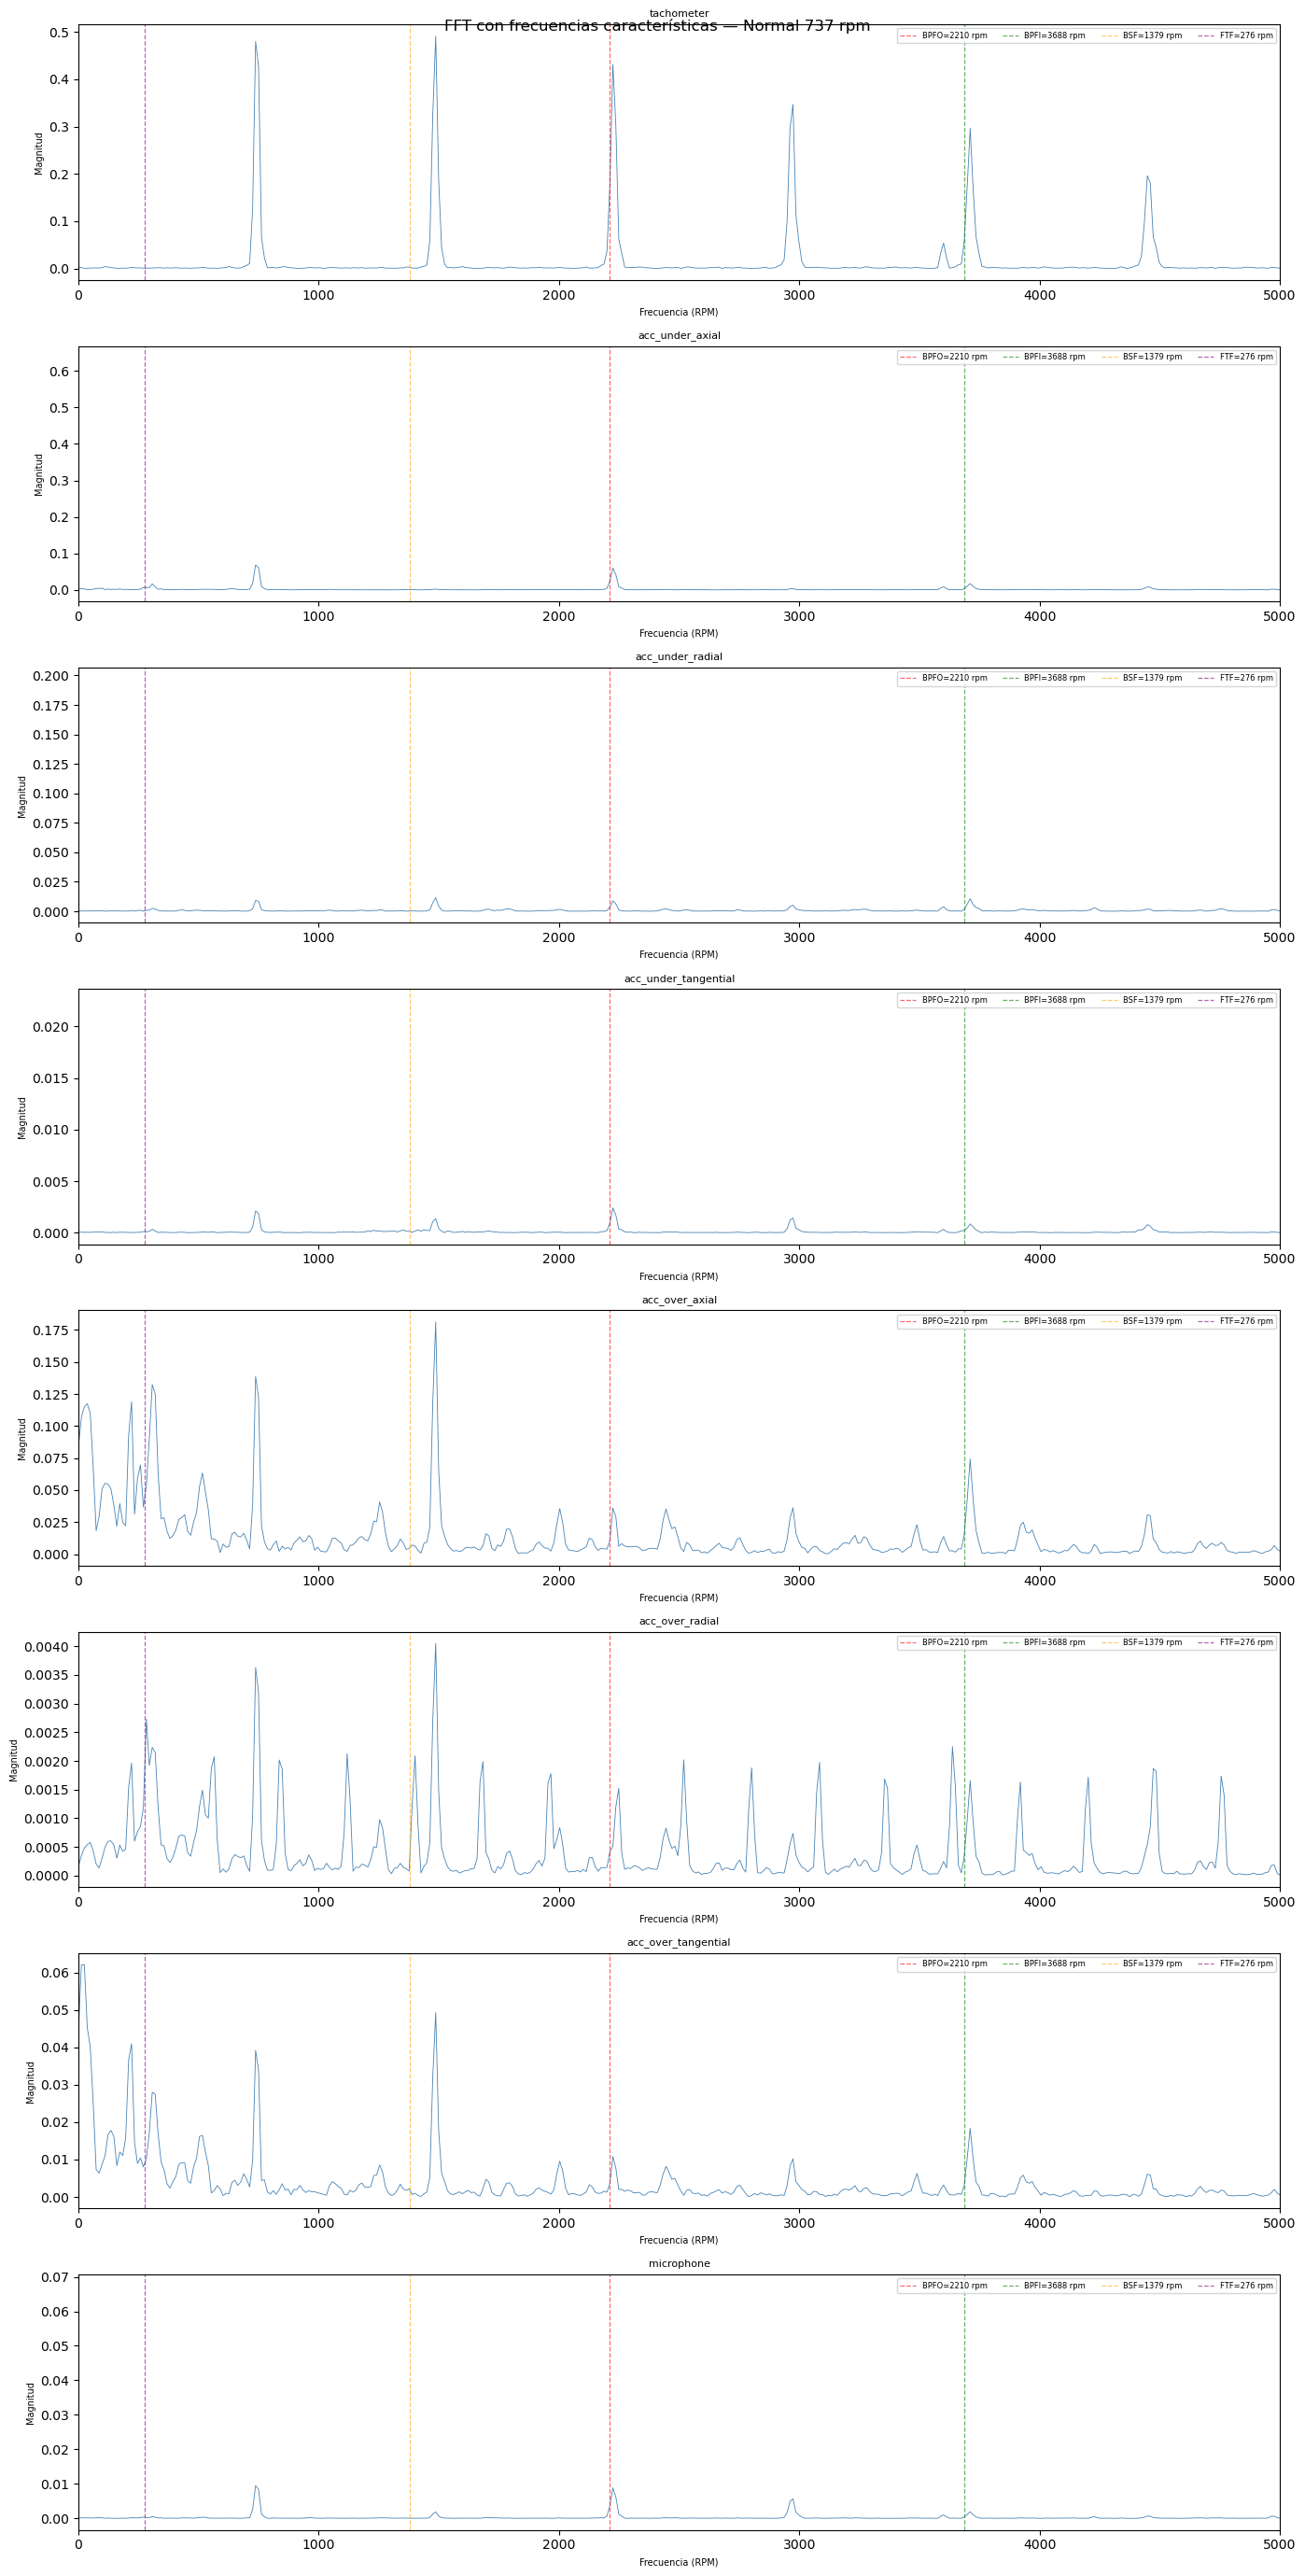



  FFT CON FRECUENCIAS CARACTERÍSTICAS — Normal 3686 rpm

  Sensor                            BPFO         BPFI          BSF          FTF
  ----------------------------------------------------------------------------
  tachometer                    0.479250     0.247841     0.000339     0.000448
  acc_under_axial               0.148631     0.026076     0.001500     0.000913
  acc_under_radial              0.031649     0.034420     0.000942     0.000386
  acc_under_tangential          0.053618     0.021187     0.000055     0.000147
  acc_over_axial                0.020205     0.015505     0.000693     0.002803
  acc_over_radial               0.002738     0.002817     0.000137     0.001553
  acc_over_tangential           0.039421     0.023694     0.000739     0.008356
  microphone                    0.010978     0.003433     0.000122     0.000118


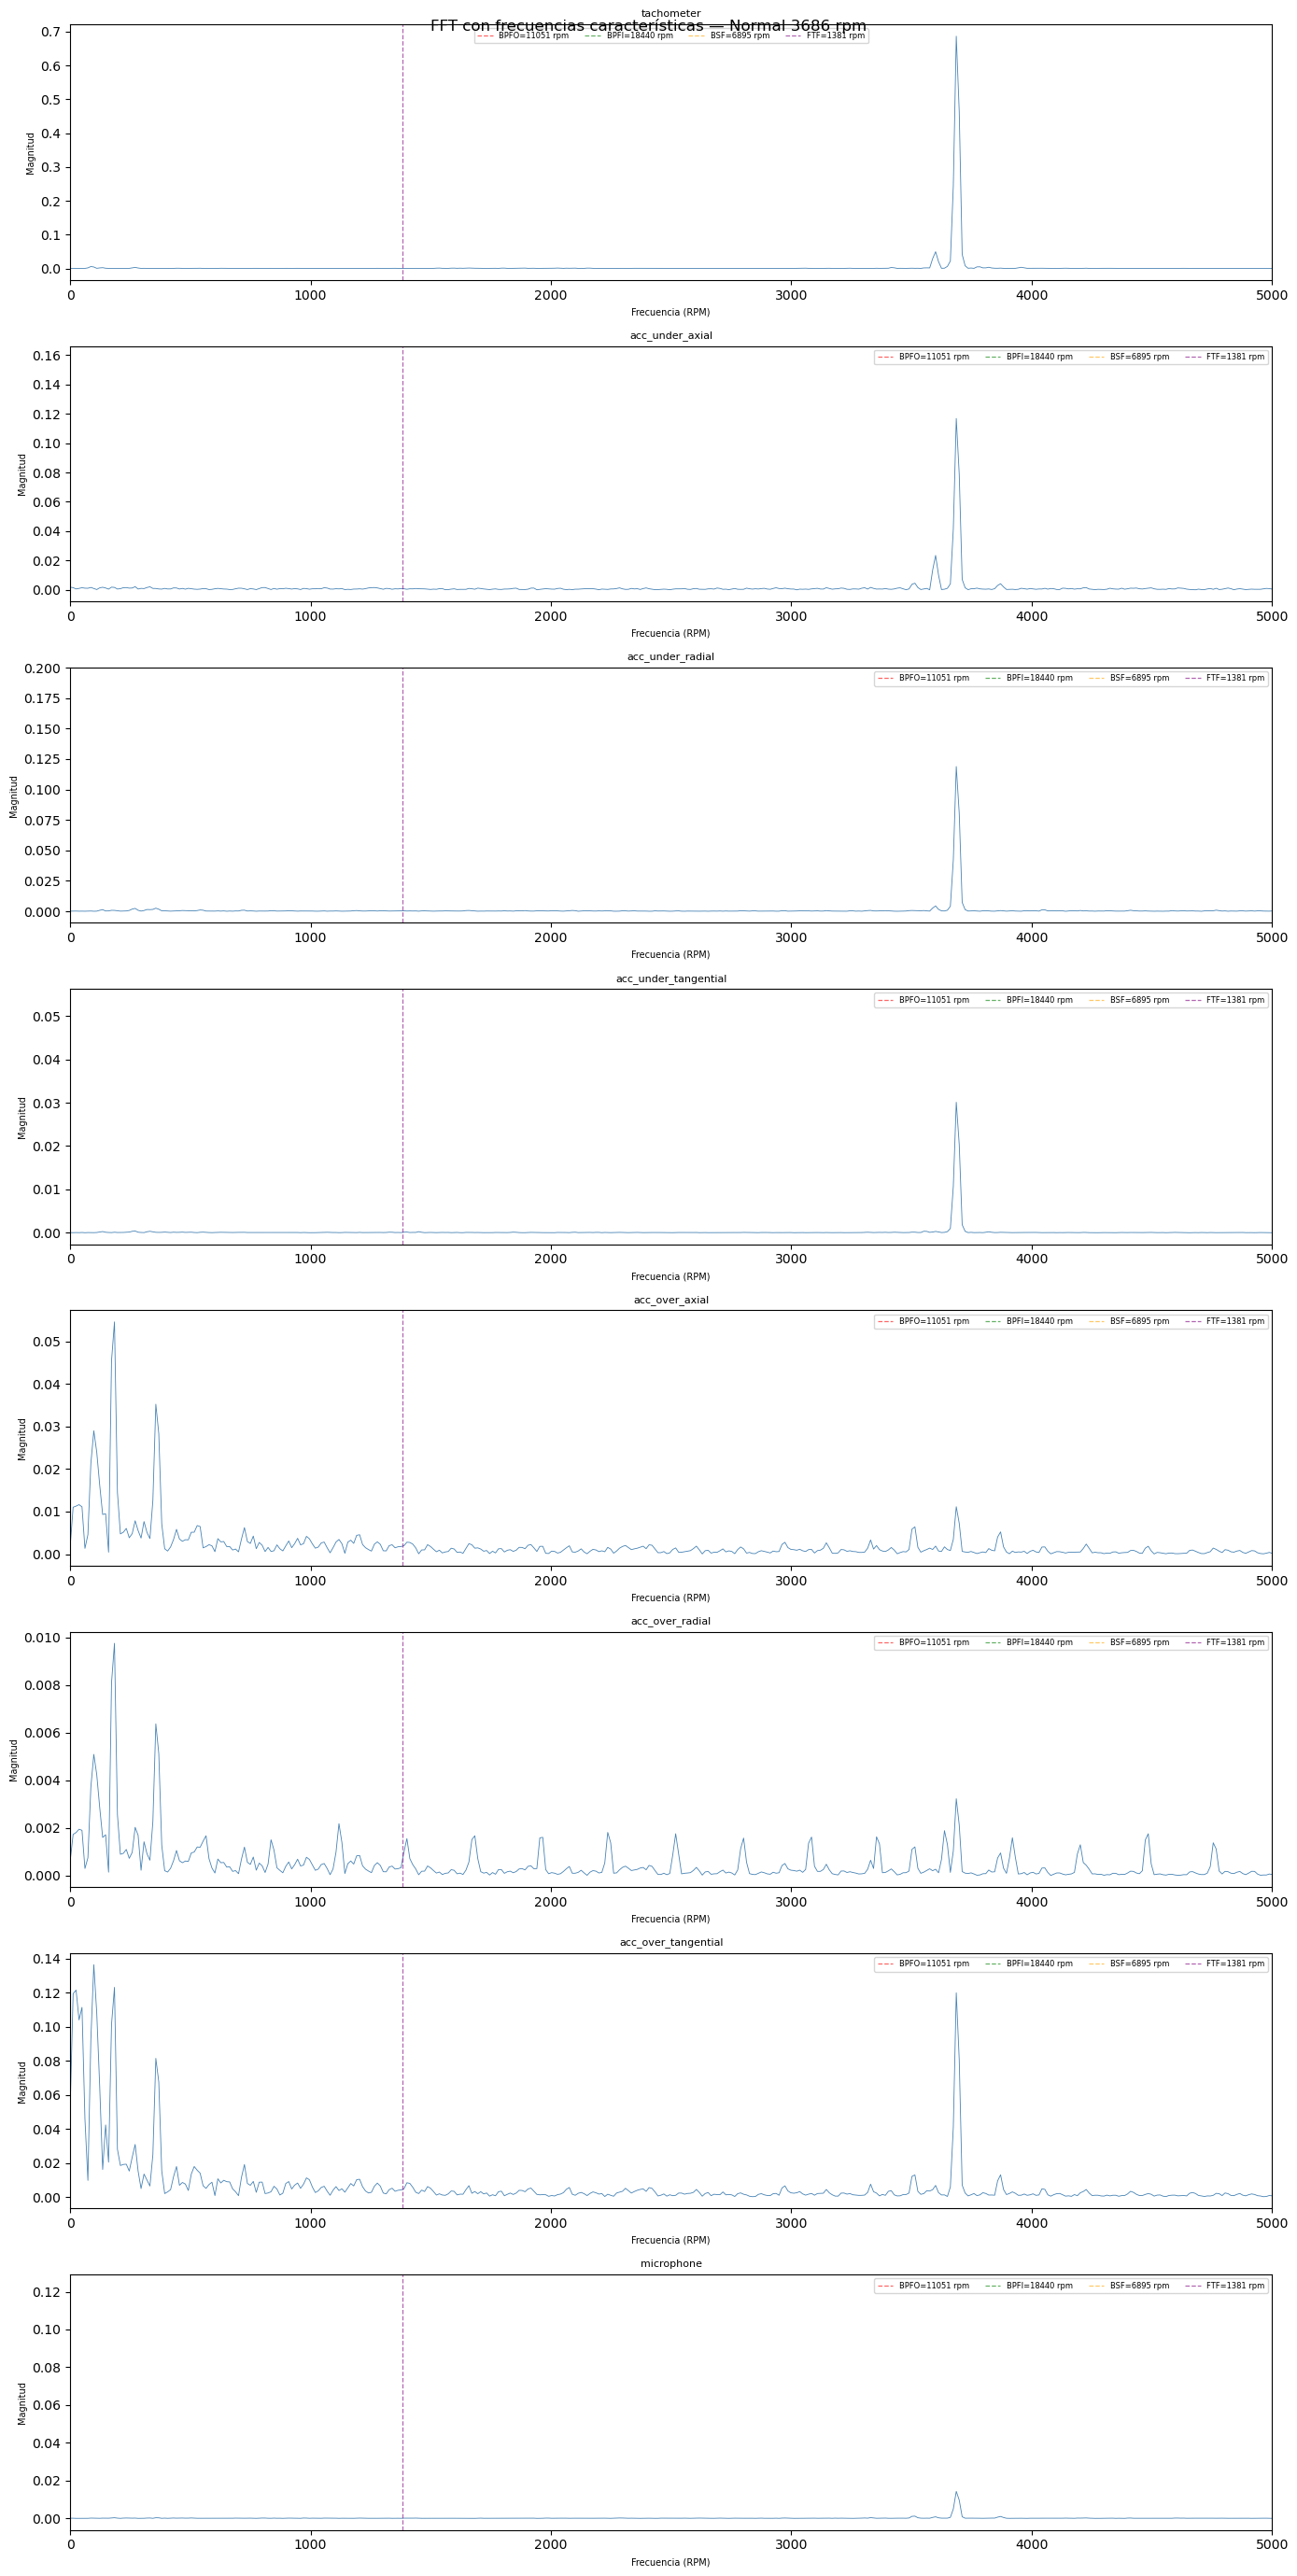

In [ ]:
def frecuencias_caracteristicas(fr):
    BPFO = (n/2) * fr * (1 - d/D)
    BPFI = (n/2) * fr * (1 + d/D)
    BSF  = (D/(2*d)) * fr * (1 - (d/D)**2)
    FTF  = (fr/2) * (1 - d/D)
    return {'BPFO': BPFO*60, 'BPFI': BPFI*60, 'BSF': BSF*60, 'FTF': FTF*60}

def dibujar_fc(ax, fr, alpha=0.6):
    fc = frecuencias_caracteristicas(fr)
    for nombre, valor, color in zip(
        ['BPFO','BPFI','BSF','FTF'],
        [fc['BPFO'], fc['BPFI'], fc['BSF'], fc['FTF']],
        ['red','green','orange','purple']
    ):
        ax.axvline(valor, color=color, linestyle='--', linewidth=0.9,
                   alpha=alpha, label=f'{nombre}={valor:.0f} rpm')

for titulo, serie in [('Normal 737 rpm', serie_low), ('Normal 3686 rpm', serie_high)]:
    señal  = serie['señal']
    fr     = serie['fr']
    fc     = frecuencias_caracteristicas(fr)

    print(f'\n{"="*70}')
    print(f'  FFT CON FRECUENCIAS CARACTERÍSTICAS — {titulo}')
    print(f'{"="*70}')

    print(f'\n  {"Sensor":<25} {"BPFO":>12} {"BPFI":>12} {"BSF":>12} {"FTF":>12}')
    print('  ' + '-'*76)

    fig, axes = plt.subplots(8, 1, figsize=(14, 28))
    fig.suptitle(f'FFT con frecuencias características — {titulo}', fontsize=12)

    for ax, (i, col) in zip(axes, enumerate(columnas)):

        # FFT para este sensor
        s, ventana = preprocesar(señal, col=i)
        rfft_out   = np.fft.rfft(s * ventana)
        fft_vals   = np.abs(rfft_out) / len(rfft_out)
        freqs_rpm  = np.fft.rfftfreq(len(s), d=1/fs) * 60

        # Gráfica
        ax.plot(freqs_rpm, fft_vals, color='steelblue', linewidth=0.6, zorder=2)
        dibujar_fc(ax, fr)
        ax.set_xlim(0, 5000)
        ax.set_xlabel('Frecuencia (RPM)', fontsize=7)
        ax.set_ylabel('Magnitud', fontsize=7)
        ax.set_title(col, fontsize=8)
        ax.legend(fontsize=6, ncol=4)

        # Fila de tabla para este sensor
        amps = {}
        for nombre, valor in fc.items():
            mask       = np.abs(freqs_rpm - valor) < 30
            amps[nombre] = float(np.max(fft_vals[mask])) if mask.any() else 0.0
        print(f'  {col:<25} {amps["BPFO"]:>12.6f} {amps["BPFI"]:>12.6f} {amps["BSF"]:>12.6f} {amps["FTF"]:>12.6f}')

    plt.tight_layout()
    plt.show()
    print()